# Notebook 03: Model Identification

This notebook examines the ACF and PACF of the first-differenced series. The ACF shows dependence on previous observations, while the PACF shows the remaining relationship at each lag after shorter lags are considered. These plots suggest candidate AR and MA orders; the later model-selection step confirms the choice using training-set AIC rather than treating the plots as a final answer.

In [1]:
# Model identification: inspect differenced fuel prices and candidate orders
import warnings

import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings("ignore")

In [2]:
# Load the cleaned monthly dataset produced by the earlier notebooks.
df = pd.read_csv("../data/dataset_final/full_data.csv")
df["date"] = pd.to_datetime(df["month"], format="%YM%m")
df = df.set_index("date").asfreq("MS")

fuel_cols = [
    "diesel_price_(GHC/litre)",
    "petrol_price_ghs/litre",
    "lpg_ghs/kg",
]
external_cols = [
    "brent_price_usd_per_barrel",
    "usd/ghs_rate",
    "consumer_price_index",
]

# The stationarity analysis established first differencing for the modeling inputs.
diff1 = df[fuel_cols + external_cols].diff().dropna()
print(f"Observations: {len(df)} ({df.index.min():%Y-%m} to {df.index.max():%Y-%m})")
print("Missing values after differencing:")
print(diff1.isna().sum())

Observations: 132 (2015-07 to 2026-06)
Missing values after differencing:
diesel_price_(GHC/litre)      0
petrol_price_ghs/litre        0
lpg_ghs/kg                    0
brent_price_usd_per_barrel    0
usd/ghs_rate                  0
consumer_price_index          0
dtype: int64


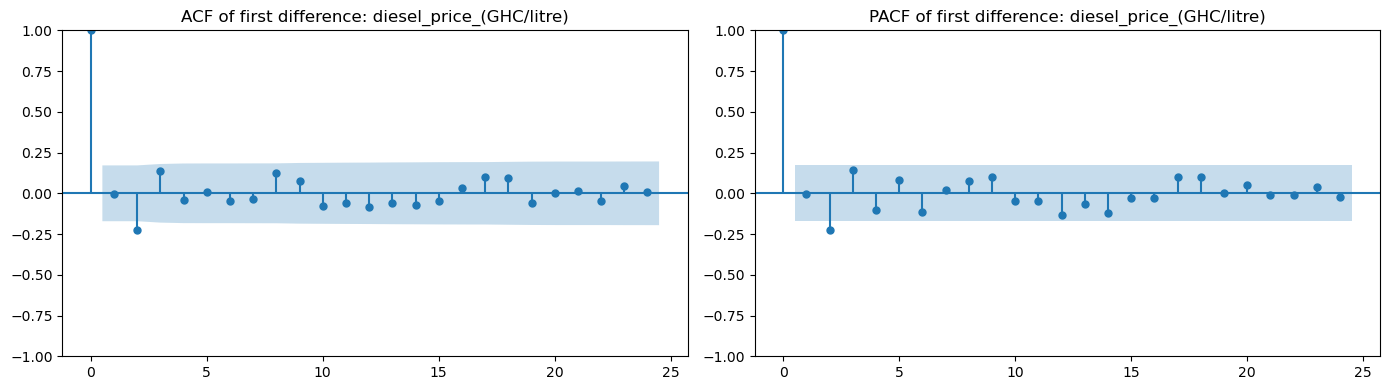

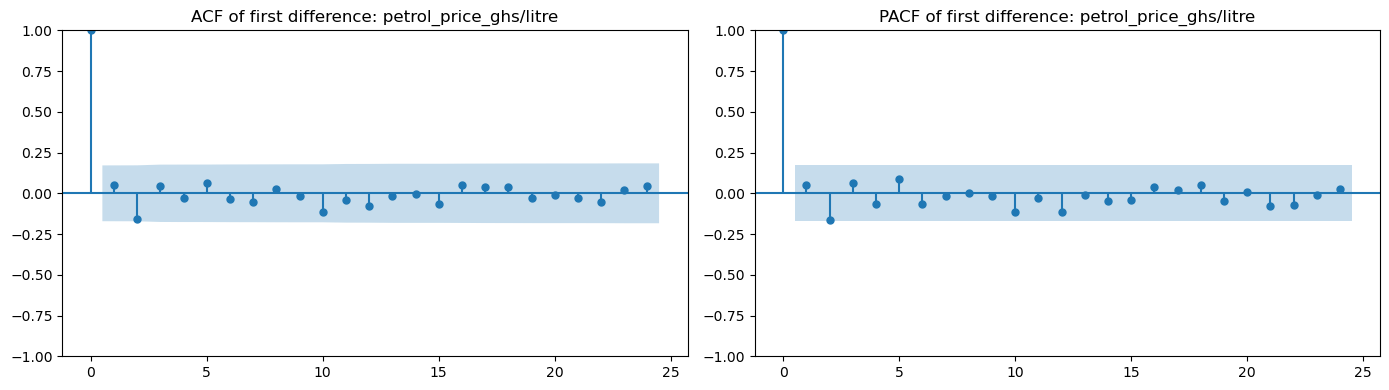

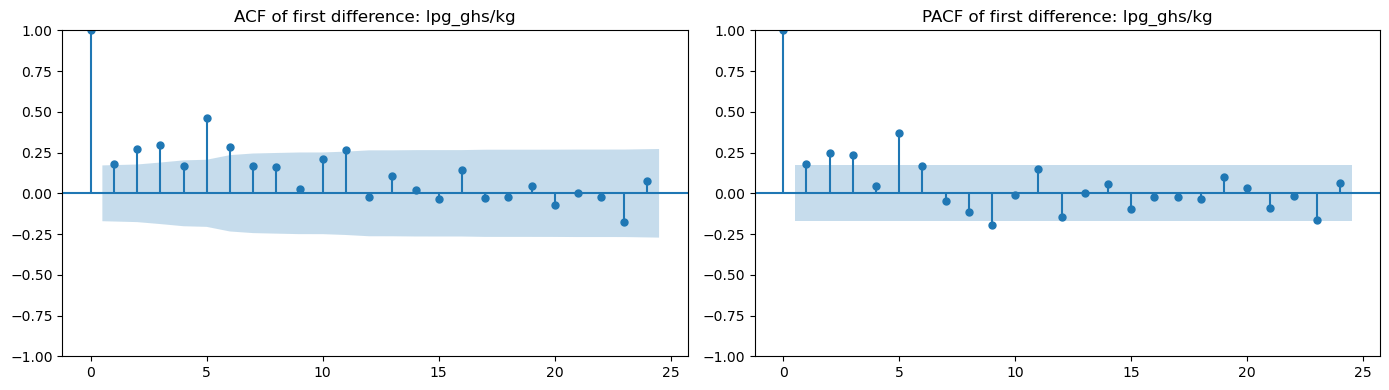

In [ ]:

for column in fuel_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    plot_acf(diff1[column], lags=min(24, len(diff1) // 2 - 1), ax=axes[0], alpha=0.05)
    plot_pacf(diff1[column], lags=min(24, len(diff1) // 2 - 1), ax=axes[1], alpha=0.05, method="ywm")
    axes[0].set_title(f"ACF of first difference: {column}")
    axes[1].set_title(f"PACF of first difference: {column}")
    plt.tight_layout()
    plt.show()